In [8]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [9]:
pd.set_option('display.max_columns', None)

In [10]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Sleep_health_and_lifestyle_dataset.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

df.head()

Dataset loaded successfully!
Shape: 374 rows, 13 columns


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
# Dataset information
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [12]:
# Statistical summary
df.describe().round(2)

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.00,374.00,374.00,374.00,374.00,374.00,374.00,374.00
mean,187.50,42.18,7.13,7.31,59.17,5.39,70.17,6816.84
std,108.11,8.67,0.80,1.20,20.83,1.77,4.14,1617.92
min,1.00,27.00,5.80,4.00,30.00,3.00,65.00,3000.00
25%,94.25,35.25,6.40,6.00,45.00,4.00,68.00,5600.00
50%,187.50,43.00,7.20,7.00,60.00,5.00,70.00,7000.00
75%,280.75,50.00,7.80,8.00,75.00,7.00,72.00,8000.00
max,374.00,59.00,8.50,9.00,90.00,8.00,86.00,10000.00


In [13]:
# Check for missing values
missing = df.isnull().sum()
print("Missing Values:")
print(missing)

Missing Values:
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


In [14]:
# Rename columns for better readability
df.columns = df.columns.str.replace(' ', '_')
print("Columns renamed:")
print(df.columns.tolist())

Columns renamed:
['Person_ID', 'Gender', 'Age', 'Occupation', 'Sleep_Duration', 'Quality_of_Sleep', 'Physical_Activity_Level', 'Stress_Level', 'BMI_Category', 'Blood_Pressure', 'Heart_Rate', 'Daily_Steps', 'Sleep_Disorder']


In [15]:
# Explore categorical variables
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Gender:
Gender
Male      189
Female    185
Name: count, dtype: int64

Occupation:
Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Scientist                4
Software Engineer        4
Sales Representative     2
Manager                  1
Name: count, dtype: int64

BMI_Category:
BMI_Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64

Blood_Pressure:
Blood_Pressure
130/85    99
140/95    65
125/80    65
120/80    45
115/75    32
135/90    27
140/90     4
125/82     4
128/85     3
132/87     3
117/76     2
130/86     2
126/83     2
119/77     2
135/88     2
128/84     2
131/86     2
139/91     2
115/78     2
129/84     2
142/92     2
118/75     2
118/76     1
122/80     1
121/79     1
Name: count, dtype: int64

Sleep_Disorder:
Sleep_Disorder
Sleep Apnea    78
Insomnia    

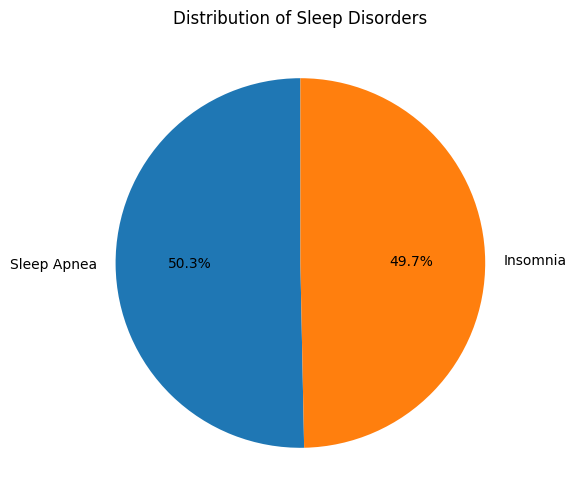

Observation: Most common sleep disorders in our dataset


In [16]:
# Sleep Disorder Distribution
plt.figure(figsize=(10, 6))
df['Sleep_Disorder'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Sleep Disorders')
plt.ylabel('')
plt.show()
print("Observation: Most common sleep disorders in our dataset")

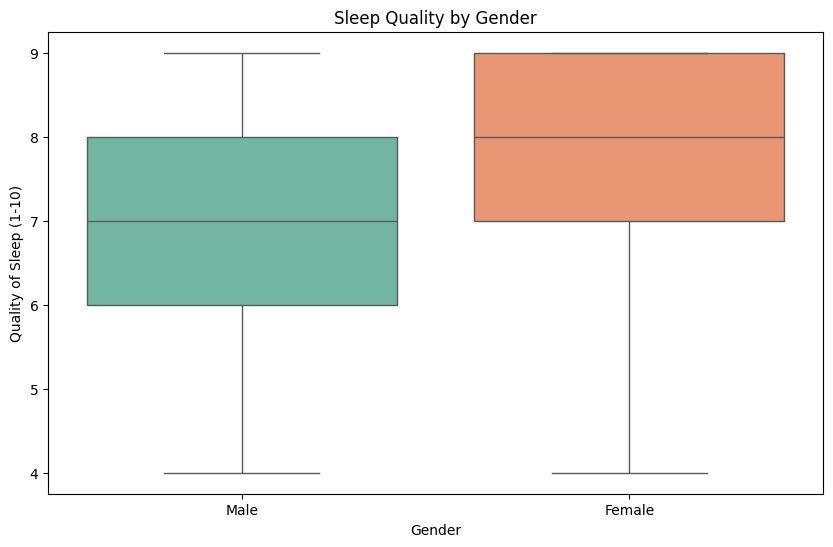

Observation: Gender distribution of sleep quality


In [17]:
# Gender vs Sleep Quality
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gender', y='Quality_of_Sleep', data=df, palette='Set2')
plt.title('Sleep Quality by Gender')
plt.xlabel('Gender')
plt.ylabel('Quality of Sleep (1-10)')
plt.show()
print("Observation: Gender distribution of sleep quality")

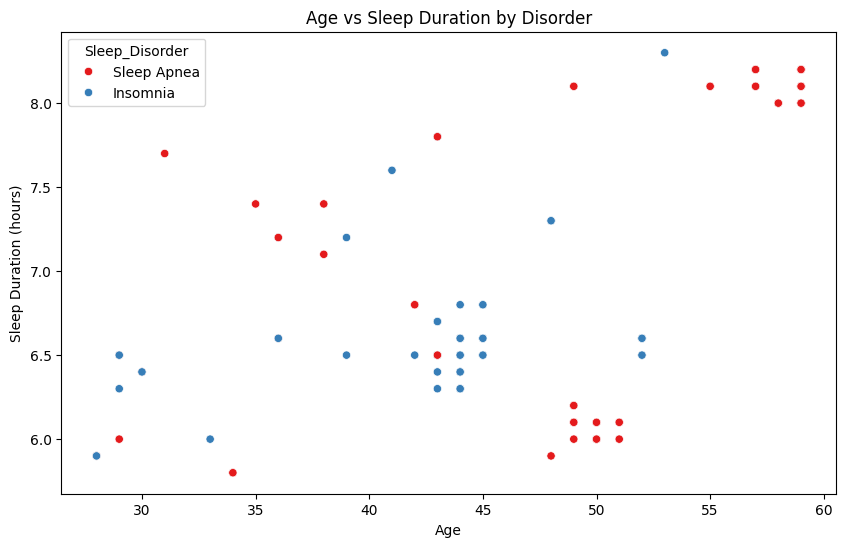

In [18]:
# Age vs Sleep Duration
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Sleep_Duration', hue='Sleep_Disorder', data=df, palette='Set1')
plt.title('Age vs Sleep Duration by Disorder')
plt.xlabel('Age')
plt.ylabel('Sleep Duration (hours)')
plt.show()

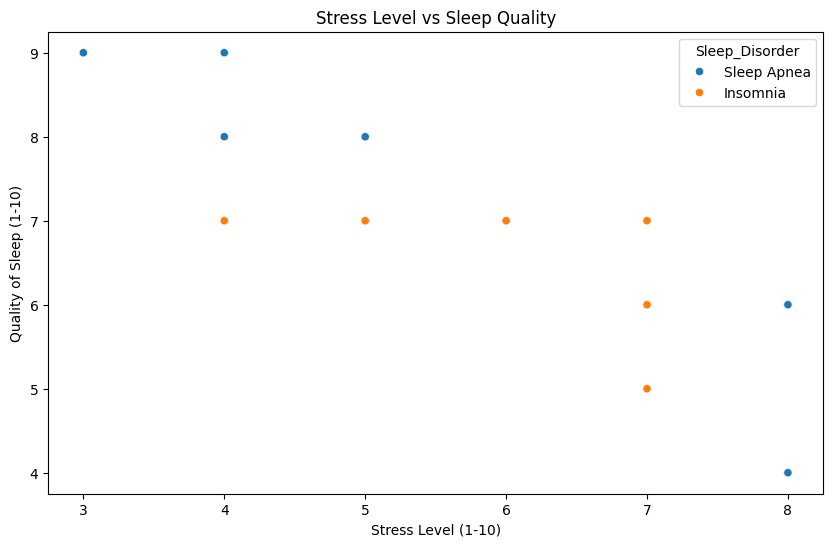

Correlation: -0.899


In [19]:
# Stress vs Sleep Quality
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Stress_Level', y='Quality_of_Sleep', hue='Sleep_Disorder', data=df)
plt.title('Stress Level vs Sleep Quality')
plt.xlabel('Stress Level (1-10)')
plt.ylabel('Quality of Sleep (1-10)')
plt.show()
corr = df['Stress_Level'].corr(df['Quality_of_Sleep'])
print(f"Correlation: {corr:.3f}")

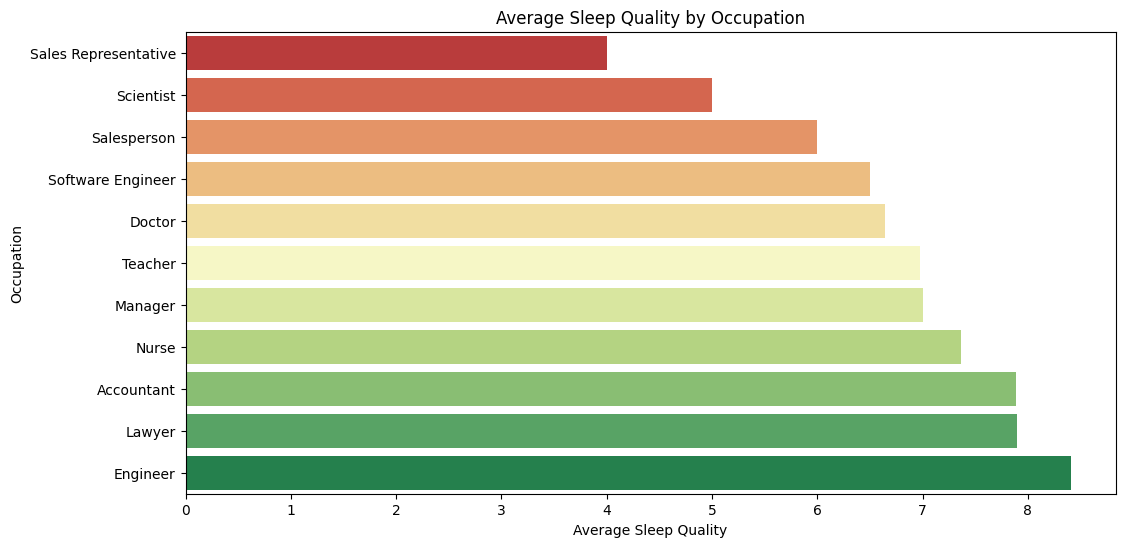

In [20]:
# Occupation vs Sleep Quality
plt.figure(figsize=(12, 6))
occ_sleep = df.groupby('Occupation')['Quality_of_Sleep'].mean().sort_values()
sns.barplot(x=occ_sleep.values, y=occ_sleep.index, palette='RdYlGn')
plt.title('Average Sleep Quality by Occupation')
plt.xlabel('Average Sleep Quality')
plt.ylabel('Occupation')
plt.show()

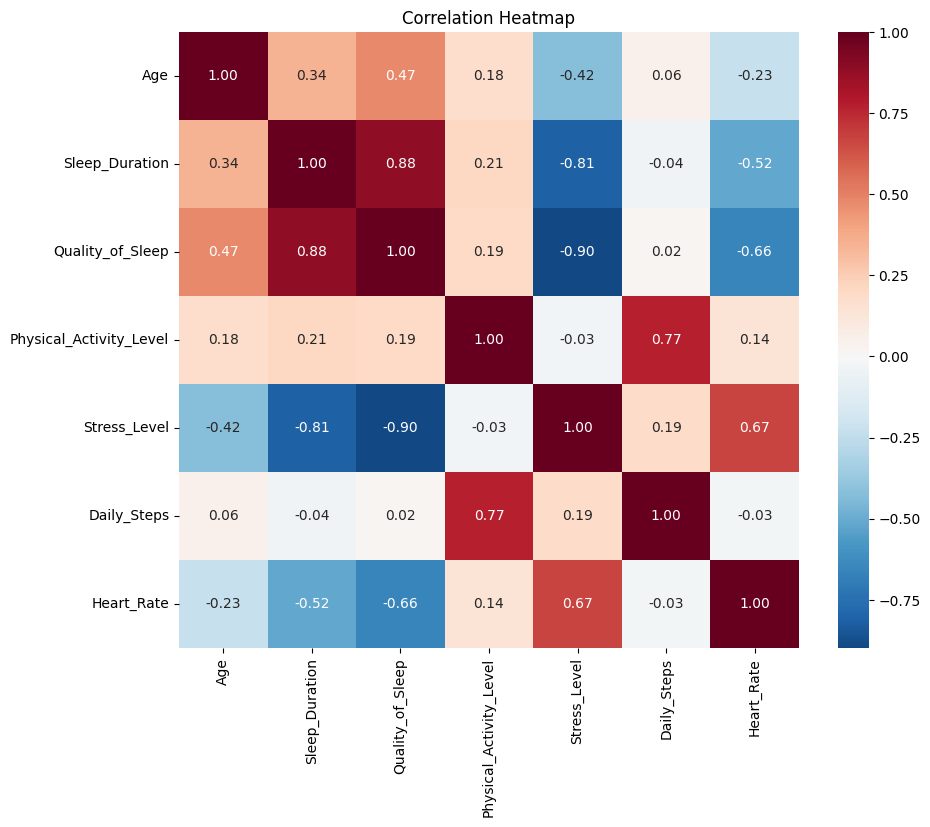

In [21]:
# Correlation Heatmap
num_cols = ['Age', 'Sleep_Duration', 'Quality_of_Sleep',
            'Physical_Activity_Level', 'Stress_Level',
            'Daily_Steps', 'Heart_Rate']
corr = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [22]:
# Import ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("ML libraries imported!")

ML libraries imported!


In [23]:
# Prepare data for ML
df_ml = df.copy()

# Encode categorical variables
le_dict = {}
cat_cols = ['Gender', 'Occupation', 'BMI_Category', 'Sleep_Disorder']

for col in cat_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    le_dict[col] = le

print("Categorical variables encoded!")

Categorical variables encoded!


In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_ml.select_dtypes(include='object').columns:
    df_ml[col] = le.fit_transform(df_ml[col])

In [25]:
# Feature selection
X = df_ml.drop(columns=['Person_ID', 'Sleep_Disorder'])
y = df_ml['Sleep_Disorder']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 299
Testing samples: 75


In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# categorical columns ko numeric me convert karo
for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.fit_transform(X_test[col])

In [27]:
# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"\nModel Accuracy: {accuracy*100:.2f}%")


Model Accuracy: 88.00%


In [28]:
# Classification Report
print("Classification Report:")
print(classification_report(y_test, predictions))

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.81      0.76        16
           1       0.85      0.69      0.76        16
           2       0.95      0.98      0.97        43

    accuracy                           0.88        75
   macro avg       0.84      0.83      0.83        75
weighted avg       0.88      0.88      0.88        75



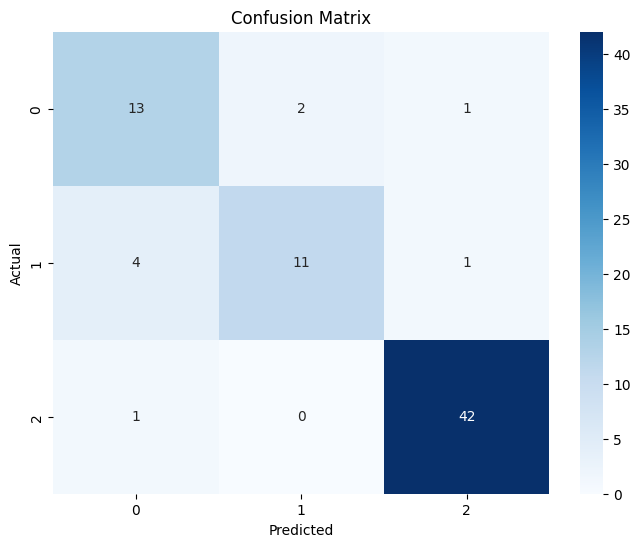

In [29]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

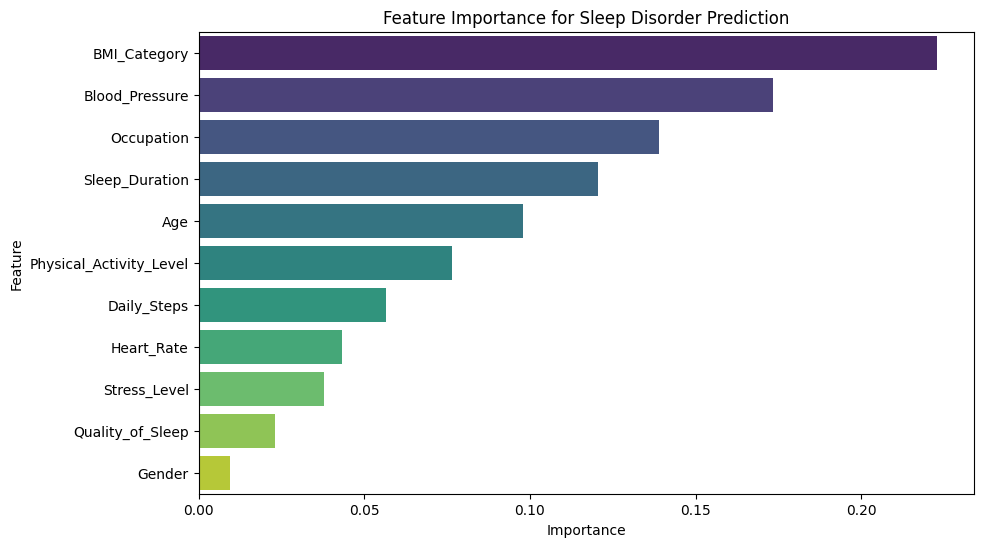


Top 5 Important Features:
          Feature  Importance
7    BMI_Category    0.222682
8  Blood_Pressure    0.173240
2      Occupation    0.138922
3  Sleep_Duration    0.120546
1             Age    0.098022


In [30]:
# Feature Importance
feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis')
plt.title('Feature Importance for Sleep Disorder Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

print("\nTop 5 Important Features:")
print(feature_imp.head())

In [33]:
import joblib

In [35]:
import pickle
with open('sleep_disorder_model.pkl', 'wb') as f:
    pickle.dump(model, f)